# **STAGE 3 - EDA AND VISUALISATION**

## **Objectives**

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## **Inputs**

* The data input I need for this section is the cleaned dataset I created in **Stage 2 - ETL**: `datasets/cleaned-data/bank-churners-cleaned.csv`

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 


---

## **Change Working Directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/credit-card-customer-churn-analysis'

---

## **Import Libraries and Packages**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
sns.set_style("whitegrid")
sns.set_palette("PiYG", n_colors=6)
colours = sns.color_palette("PiYG", n_colors=2)

---

## **Load the Dataset**

In [5]:
# Load the cleaned dataset
df_vis = pd.read_csv("datasets/cleaned-data/bank-churners-cleaned.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_vis.head()

,anonymised_clientnum,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag_Binary
0,022e52f0a251431f954db620fd0c87ac3c523c60cc5980...,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777.0,11914.0,1.335,1144.0,42,1.625,0.061,0
1,2731de4ed9ecb2a3ab828448bfda6137e5c7571e1f7576...,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864.0,7392.0,1.541,1291.0,33,3.714,0.105,0
2,75dac624c2bbdb15b16abc0350820bcf598c012a76b102...,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0.0,3418.0,2.594,1887.0,20,2.333,0.000,0
3,1aaada0cd1f7dc23d83a171beec9f398cfac1471841843...,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517.0,796.0,1.405,1171.0,20,2.333,0.760,0
4,1811f55b3210153f77e41ceceb61cc181d2edc4e65947e...,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0.0,4716.0,2.175,816.0,28,2.500,0.000,0


---

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Attrition Flag - Analysis of Target Variable**

Seeing as `Attrition_Flag` (or at least, `Attrition_Flag_Binary`) is going to be the target variable in **Stage 4 - Machine Learning**, it will be good to get a sense of the split between existing and attrited customers.

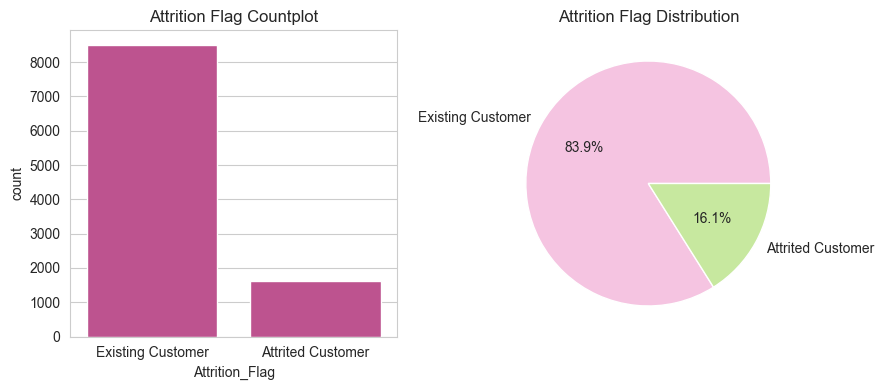

In [7]:
# Map a countplot and pie chart for attrition flag variable
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)

sns.countplot(data=df_vis, x="Attrition_Flag", ax=axes[0])
axes[0].set_title("Attrition Flag Countplot")

axes[1].pie(
    df_vis["Attrition_Flag"].value_counts(),
    labels=df_vis["Attrition_Flag"].value_counts().index, 
    colors = colours, autopct="%1.1f%%")
axes[1].set_title("Attrition Flag Distribution")

plt.show()

Given what we can see here, the `Attrition_Flag` values are imbalanced. This is very important to note because it affects how we will need to look at machine learning - accuracy alone will not be a good judge of the performance of a machine learning model. 

### **1.2 Demographic Variables - Gender, Marital Status and Education Level**

#### **1.2.1 Countplots for Demographic Variables**

The first thing I am going to do is plot three separate countplots for demographic variables showing those attrited vs not.

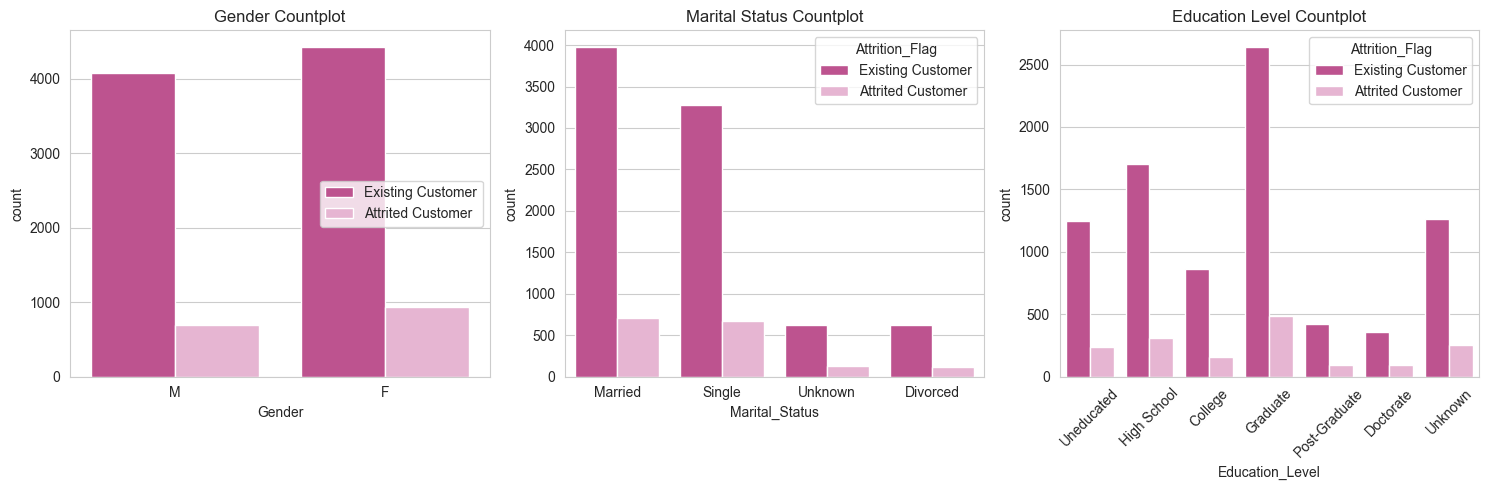

In [8]:
# Map a countplot for demographic variables Gender, Marital_Status and Education_Level
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), tight_layout=True)

# Plot countplot for Gender
sns.countplot(data=df_vis, x="Gender", hue="Attrition_Flag", ax=axes[0])
axes[0].set_title("Gender Countplot")
axes[0].legend(loc="center right")

# Plot countplot for Marital_Status
sns.countplot(data=df_vis, x="Marital_Status", hue="Attrition_Flag", ax=axes[1])
axes[1].set_title("Marital Status Countplot")

# Set order of the Education_Level variable to ensure "Unknown" is at the end
education_level_order = [
    "Uneducated",
    "High School",
    "College",
    "Graduate",
    "Post-Graduate",
    "Doctorate",
    "Unknown"
]

# Plot countplot for Education_Level
sns.countplot(data=df_vis, x="Education_Level", order=education_level_order, hue="Attrition_Flag", ax=axes[2])
axes[2].set_title("Education Level Countplot")
axes[2].tick_params(axis='x', rotation=45)

plt.show()

> *Notes on Process*: 
<br><br>The following [Stack Overflow](https://stackoverflow.com/questions/10998621/rotate-axis-tick-labels) forum was incredibly helpful in finding out how to rotate my x-ticks to make them fit.
<br><br>I used the [Matplotlib Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) for `.legend` to move the legend in the Gender plot to allow viewers to see the top of the bar.
<br><br>

#### **1.2.2 Proportion Bar Charts**

The biggest problem with these three countplots is that because the `Attrition_Flag` variable is so imbalanced (Existing Customers make up nearly 84% and Attrited just over 16%), the countplots essentially just reflect this imbalance and there's not a lot of *new* information we can take away. It is very difficult to see if there is any difference in the proportions between categories:
* e.g. Is there a bigger proportion of Attrited Customers in the `Married` category vs in the `Single` category for `Marital_Status`?

I am therefore going to create three separate proportion bar charts which will show, within each category in `Gender`/`Marital_Status`/`Education_Level`, what proportion is existing vs attrited. This will allow me to measure attrition rate across groups fairly.

> *Notes on Process*: 
<br><br>This was a new concept to me, so it involved a lot of research to work out how best to manage this. A massive help in terms of knowing what to do was this [Stack Overflow](https://stackoverflow.com/questions/34615854/countplot-with-normalized-y-axis-per-group) forum. I had to use Generative AI (Claude Sonnet 5) to research some of the methods applied to my `df_vis`, including why the order of the methods mattered.
<br><br>Particularly important is the order of `.groupby` *followed by* `value_counts(normalize=True)`. Because `normalize=True` converts each count into a proportion of the total, it was essential to use `.groupby()` first.
<br><br>To clarify the process more clearly, I have ensured to include comments to outline each process.

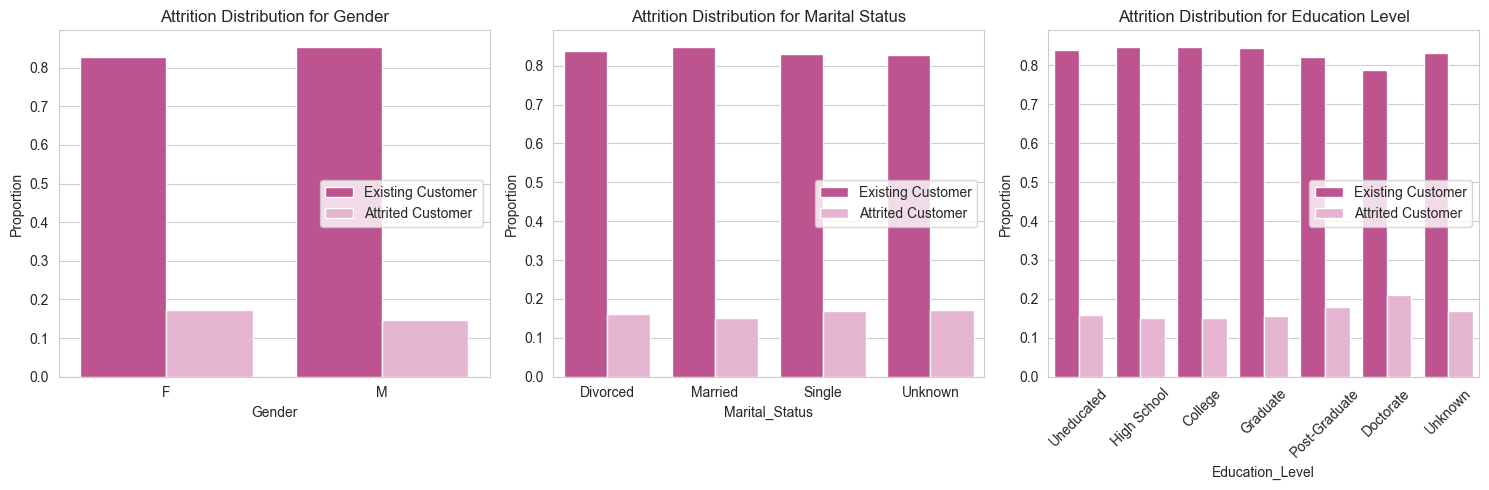

In [9]:
# Map a barplot of proportions for demographic variables Gender, Marital_Status and Education_Level
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), tight_layout=True)

# Attrition_Flag Distribution by Gender
gender_attrition_proportions = (df_vis.groupby('Gender')['Attrition_Flag'] # Split the data by Gender category (M and F) and pull out just the Attrition_Flag data
                                .value_counts(normalize=True) # Within each Gender Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                .rename("Proportion")
                                .reset_index())

# Plot Attrition_Flag Distribution by Gender in a barplot
sns.barplot(data=gender_attrition_proportions, x='Gender', y='Proportion', hue='Attrition_Flag', ax=axes[0])
axes[0].set_title("Attrition Distribution for Gender")
axes[0].legend(loc="center right")

# Attrition_Flag Distribution by Marital_Status
marital_attrition_proportions = (df_vis.groupby('Marital_Status')['Attrition_Flag'] # Split the data by Marital_Status category and pull out just the Attrition_Flag data
                                .value_counts(normalize=True) # Within each Marital_Status Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                .rename("Proportion")
                                .reset_index())

# Plot Attrition_Flag Distribution by Marital_Status in a barplot
sns.barplot(data=marital_attrition_proportions, x='Marital_Status', y='Proportion', hue='Attrition_Flag', ax=axes[1])
axes[1].set_title("Attrition Distribution for Marital Status")
axes[1].legend(loc="center right")

# Attrition_Flag Distribution by Education_Level
education_attrition_proportions = (df_vis.groupby('Education_Level')['Attrition_Flag'] # Split the data by Education_Level category and pull out just the Attrition_Flag data
                                    .value_counts(normalize=True) # Within each Education_Level Category, calculate the proportion of each Attrition_Flag category (Existing Customer and Attrited Customer)
                                    .rename("Proportion")
                                    .reset_index())

# Plot Attrition_Flag Distribution by Education_Level in a barplot
sns.barplot(data=education_attrition_proportions, x='Education_Level', order=education_level_order, y='Proportion', hue='Attrition_Flag', ax=axes[2])
axes[2].set_title("Attrition Distribution for Education Level")
axes[2].legend(loc="center right")
axes[2].tick_params(axis='x', rotation=45)

plt.show()

##### **What do these bar charts tell us?**

These bar charts appear to show us that every category's proportions hover around roughly 0.84 for existing and 0.16 for attrited, which matches the proportions of `Existing Customer` (84%) vs `Attrited Customer` in `Attrition_Flag` very closely.

It suggests that these demographic variables are weak predictors of attrition. To examine this in a bit more detail, I will print the proportion values using `.pivot()`. 

> *Notes on Process*:
<br><br>Originally, I wanted to print the proportion values on the charts themselves; however, this made them very difficult to read. 
<br><br>Therefore, I consulted Generative AI (Claude Sonnet 5) for a solution to print all of these proportions in a table and it gave me the code for `.pivot()`.
<br><br>

In [10]:
# Print proportions of Attrition_Flag by Gender, Marital_Status and Education_Level
print("="*55)
print("PROPORTIONS OF ATTRITION FLAG BY GENDER")
print("="*55)
print(gender_attrition_proportions.pivot(index="Gender", columns="Attrition_Flag", values="Proportion").round(3))

print("\n" + "="*55)
print("PROPORTIONS OF ATTRITION FLAG BY MARITAL STATUS")
print("="*55)
print(marital_attrition_proportions.pivot(index="Marital_Status", columns="Attrition_Flag", values="Proportion").round(3))

print("\n" + "="*55)
print("PROPORTIONS OF ATTRITION FLAG BY EDUCATION LEVEL")
print("="*55)
print(education_attrition_proportions.pivot(index="Education_Level", columns="Attrition_Flag", values="Proportion").round(3))

PROPORTIONS OF ATTRITION FLAG BY GENDER
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                           0.174              0.826
M                           0.146              0.854

PROPORTIONS OF ATTRITION FLAG BY MARITAL STATUS
Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                    0.162              0.838
Married                     0.151              0.849
Single                      0.169              0.831
Unknown                     0.172              0.828

PROPORTIONS OF ATTRITION FLAG BY EDUCATION LEVEL
Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                      0.152              0.848
Doctorate                    0.211              0.789
Graduate                     0.156              0.844
High School                  0.152              0.848
Post-Gr

These proportion values show that there is a slight variation between the proportions for each variable's category, but nothing glaring. There are no instances where `Existing Customer` proportion sits above `Attrited Customer`. 